# UCRIS — Random Forest Model
## Unified Customer Risk Intelligence System

### Project Overview
Post-loan monitoring system that continuously analyzes customer
financial behavior to detect early signs of financial stress and
predict risk escalation before default occurs.

- **Dataset:** UCI Credit Card Default (30,000 customers, 25 features)
- **Approach:** Dual-task classification using engineered temporal features
- **Innovation:** Behavioral drift detection using 6-month payment history

---

### This Notebook — Random Forest

| Property | Detail |
|---|---|
| Role | Baseline Model 2 — strong non-linear benchmark |
| Task | Financial Stress Detection (Task A) — 3-class |
| Output | Low / Medium / High stress level |
| Metric | Weighted F1 Score |
| Purpose | Beats LR (0.8677) — must be beaten by joint model |

**Why Random Forest here:**
Random Forest captures non-linear relationships and feature
interactions that Logistic Regression cannot. It handles
class imbalance well via class_weight and provides native
feature importance. If RF significantly outperforms LR,
it proves the stress detection problem has non-linear
structure — which justifies the complexity of the joint
model.

**Key difference from LR notebook:**
- No need for feature scaling (RF is tree-based)
- Will use class_weight='balanced_subsample' 
- Expect better Medium class F1 due to non-linearity
- Feature importance from trees vs SHAP coefficients

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split,
                                     cross_val_score,
                                     StratifiedKFold,
                                     RandomizedSearchCV)
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             ConfusionMatrixDisplay)
import shap
import joblib
import os
import json
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.random.seed(42)

# ── Load data ─────────────────────────────────────────
df_raw = pd.read_excel('../credit_default.csv',
                        header=1,
                        engine='xlrd')

print(f"✓ All imports successful")
print(f"✓ Dataset loaded: {df_raw.shape}")

✓ All imports successful
✓ Dataset loaded: (30000, 25)


In [2]:
print("=" * 55)
print("DATA PREPARATION — CLEAN + ENGINEER + LABEL")
print("=" * 55)

# ── Step 1: Clean ─────────────────────────────────────
df = df_raw.copy()
df = df.drop('ID', axis=1)
df = df.rename(columns={'default payment next month': 'default'})
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0:3})

pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                'PAY_AMT4','PAY_AMT5','PAY_AMT6']
for col in pay_amt_cols:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

print("✓ Cleaning complete")

# ── Step 2: Feature Engineering ───────────────────────
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols  = ['PAY_0','PAY_2','PAY_3',
             'PAY_4','PAY_5','PAY_6']
x = np.arange(6)

# Utilization
for i, col in enumerate(bill_cols, 1):
    df[f'UTIL_{i}'] = (
        df[col] / df['LIMIT_BAL'].replace(0, np.nan)
    ).clip(0, 1).fillna(0)

util_cols = [f'UTIL_{i}' for i in range(1, 7)]
df['avg_utilization'] = df[util_cols].mean(axis=1)
df['util_recent']     = df[['UTIL_1','UTIL_2']].mean(axis=1)
df['util_early']      = df[['UTIL_5','UTIL_6']].mean(axis=1)
df['util_change']     = df['util_recent'] - df['util_early']

# Payment delay features
pay_matrix = df[pay_cols].values.astype(float)
df['pay_delay_trend'] = np.array([
    np.polyfit(x, row, 1)[0] for row in pay_matrix
])
df['avg_pay_delay']      = df[pay_cols].mean(axis=1)
df['consecutive_delays'] = df[pay_cols].gt(0).sum(axis=1)

# Repayment ratio
for i, (p, b) in enumerate(zip(pay_amt_cols, bill_cols), 1):
    df[f'REPAY_RATIO_{i}'] = np.where(
        df[b] > 0,
        (df[p] / df[b]).clip(0, 1),
        1.0
    )
repay_cols = [f'REPAY_RATIO_{i}' for i in range(1, 7)]
df['avg_repay_ratio'] = df[repay_cols].mean(axis=1)

# Volatility and trend
df['spending_volatility'] = np.log1p(df[bill_cols].std(axis=1))
pay_amt_matrix = df[pay_amt_cols].values.astype(float)
df['pay_amt_trend'] = np.sign(
    np.array([np.polyfit(x, row, 1)[0] 
               for row in pay_amt_matrix])
) * np.log1p(np.abs(
    np.array([np.polyfit(x, row, 1)[0] 
               for row in pay_amt_matrix])
))

print("✓ Feature engineering complete")

# ── Step 3: Label Engineering ─────────────────────────
def assign_stress_label(row):
    if row['PAY_0'] >= 2 or row['avg_utilization'] > 0.80:
        return 2
    elif (row['PAY_0'] == 1 or
          (0.50 < row['avg_utilization'] <= 0.80)):
        return 1
    else:
        return 0

def assign_escalation_label(row):
    pay_recent       = (row['PAY_0'] + row['PAY_2']) / 2
    pay_early        = (row['PAY_5'] + row['PAY_6']) / 2
    delay_escalating = pay_recent > pay_early
    util_escalating  = row['util_change'] > 0.15
    return 1 if (delay_escalating or util_escalating) else 0

df['stress_label']     = df.apply(assign_stress_label, axis=1)
df['escalation_label'] = df.apply(assign_escalation_label, axis=1)

stress_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print("✓ Label engineering complete")

# ── Step 4: Feature Selection + Encoding ──────────────
temporal_features     = [
    'avg_utilization', 'util_change', 'avg_pay_delay',
    'consecutive_delays', 'avg_repay_ratio',
    'spending_volatility', 'pay_delay_trend',
    'pay_amt_trend', 'LIMIT_BAL'
]
categorical_features  = ['SEX', 'EDUCATION', 'MARRIAGE']
feature_cols          = temporal_features + categorical_features

df_model = df[feature_cols + 
              ['stress_label', 'escalation_label', 
               'default']].copy()
df_model = pd.get_dummies(df_model,
                           columns=categorical_features,
                           drop_first=True)

feature_columns = [c for c in df_model.columns
                   if c not in ['stress_label',
                                'escalation_label',
                                'default']]

X = df_model[feature_columns]
y = df_model['stress_label']

# ── Step 5: Train/Test Split ───────────────────────────
# NOTE: No scaling for Random Forest — tree models
# do not require feature normalization
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✓ Feature selection + encoding complete")
print("✓ Train/test split complete (no scaling needed)")
print(f"\n── Summary ─────────────────────────────────────────")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Features: {feature_columns}")
print(f"\n  Stress label distribution (train):")
for k, v in sorted(y_train.value_counts().items()):
    pct = v / len(y_train) * 100
    print(f"    {stress_map[k]:8s}: {v:,} ({pct:.1f}%)")
print(f"\n✓ Data ready for Random Forest training")

DATA PREPARATION — CLEAN + ENGINEER + LABEL
✓ Cleaning complete
✓ Feature engineering complete
✓ Label engineering complete
✓ Feature selection + encoding complete
✓ Train/test split complete (no scaling needed)

── Summary ─────────────────────────────────────────
  X_train : (24000, 15)
  X_test  : (6000, 15)
  Features: ['avg_utilization', 'util_change', 'avg_pay_delay', 'consecutive_delays', 'avg_repay_ratio', 'spending_volatility', 'pay_delay_trend', 'pay_amt_trend', 'LIMIT_BAL', 'SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']

  Stress label distribution (train):
    Low     : 12,259 (51.1%)
    Medium  : 6,216 (25.9%)
    High    : 5,525 (23.0%)

✓ Data ready for Random Forest training


PHASE 5 — SHORTLIST MODELS (CROSS VALIDATION)
Running 5-fold stratified cross validation...
Metric: Weighted F1 Score
────────────────────────────────────────────────────────────────────────
Configuration                             Mean F1     Std F1     Min F1     Max F1
────────────────────────────────────────────────────────────────────────
RF — default                               0.9764     0.0029     0.9718     0.9810
RF — balanced                              0.9776     0.0027     0.9722     0.9796
RF — balanced_subsample                    0.9772     0.0025     0.9728     0.9802
RF — balanced + 200 trees                  0.9776     0.0027     0.9726     0.9804
RF — balanced + max_depth=10               0.9710     0.0028     0.9681     0.9751
────────────────────────────────────────────────────────────────────────

✓ Best configuration : RF — balanced + 200 trees
  Mean F1            : 0.9776
  Std F1             : 0.0027

── Comparison vs LR Baseline ───────────────────────
 

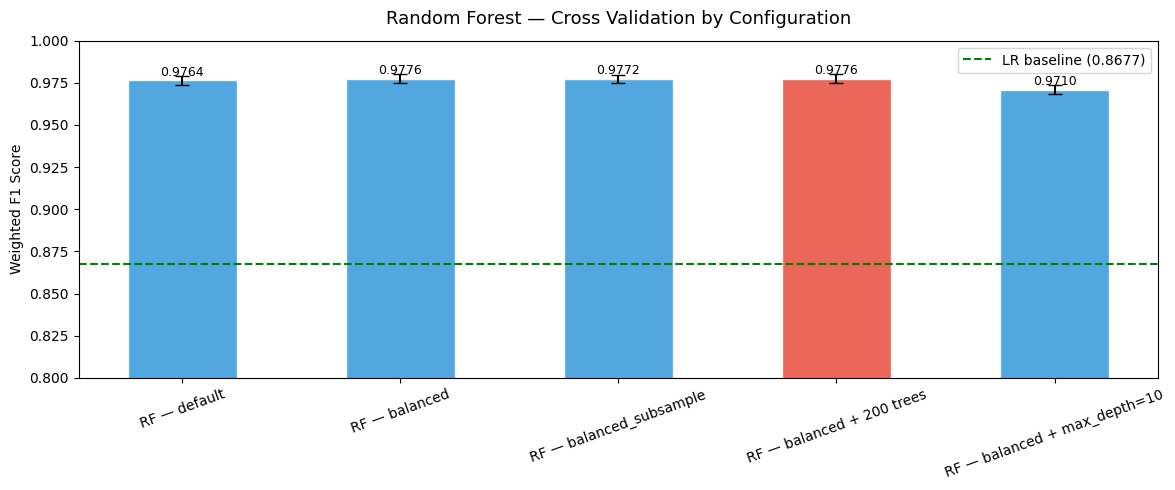

In [3]:
print("=" * 55)
print("PHASE 5 — SHORTLIST MODELS (CROSS VALIDATION)")
print("=" * 55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

configs = {
    'RF — default' : RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    'RF — balanced' : RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'RF — balanced_subsample' : RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
    'RF — balanced + 200 trees' : RandomForestClassifier(
        class_weight='balanced',
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'RF — balanced + max_depth=10' : RandomForestClassifier(
        class_weight='balanced',
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
}

print(f"Running 5-fold stratified cross validation...")
print(f"Metric: Weighted F1 Score")
print(f"{'─'*72}")
print(f"{'Configuration':<38} {'Mean F1':>10} "
      f"{'Std F1':>10} {'Min F1':>10} {'Max F1':>10}")
print(f"{'─'*72}")

results = {}
for name, model in configs.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    )
    results[name] = scores
    print(f"{name:<38} {scores.mean():>10.4f} "
          f"{scores.std():>10.4f} "
          f"{scores.min():>10.4f} "
          f"{scores.max():>10.4f}")

print(f"{'─'*72}")
best_config = max(results, key=lambda k: results[k].mean())
print(f"\n✓ Best configuration : {best_config}")
print(f"  Mean F1            : {results[best_config].mean():.4f}")
print(f"  Std F1             : {results[best_config].std():.4f}")

# Compare against LR baseline
lr_baseline = 0.8677
best_mean   = results[best_config].mean()
improvement = (best_mean - lr_baseline) * 100

print(f"\n── Comparison vs LR Baseline ───────────────────────")
print(f"  LR baseline F1  : {lr_baseline:.4f}")
print(f"  Best RF CV F1   : {best_mean:.4f}")
print(f"  Improvement     : {improvement:+.2f} percentage points")
print(f"  Status          : "
      f"{'✓ Beats LR' if best_mean > lr_baseline else '✗ Does not beat LR'}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['#e74c3c' if n == best_config 
          else '#3498db' for n in names]

bars = ax.bar(names, means, yerr=stds,
              color=colors, edgecolor='white',
              capsize=5, width=0.5, alpha=0.85)
ax.axhline(y=lr_baseline, color='green',
           linestyle='--', linewidth=1.5,
           label=f'LR baseline ({lr_baseline})')
ax.set_title('Random Forest — Cross Validation by Configuration',
             fontsize=13, pad=12)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0.80, 1.0)
ax.tick_params(axis='x', rotation=20)
ax.legend()
for bar, mean in zip(bars, means):
    ax.annotate(f'{mean:.4f}',
                (bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
print("=" * 55)
print("PHASE 6 — HYPERPARAMETER FINE TUNING")
print("=" * 55)
print("Base: RF balanced + 200 trees (best from Phase 5)")
print("Method: RandomizedSearchCV, 5-fold, 30 iterations")
print()

param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 15, 20, 25, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'class_weight'      : ['balanced', 
                           'balanced_subsample'],
    'bootstrap'         : [True, False]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator           = rf_base,
    param_distributions = param_dist,
    n_iter              = 30,
    cv                  = cv,
    scoring             = 'f1_weighted',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    return_train_score  = True
)

random_search.fit(X_train, y_train)

print(f"\n✓ Best parameters found:")
print(f"{'─'*45}")
for k, v in random_search.best_params_.items():
    print(f"  {k:<22}: {v}")

print(f"\n✓ Best CV F1 : {random_search.best_score_:.4f}")

# Top 5 configurations
results_df = pd.DataFrame(random_search.cv_results_)
top5 = results_df.nlargest(5, 'mean_test_score')[[
    'param_n_estimators', 'param_max_depth',
    'param_max_features', 'param_min_samples_split',
    'param_class_weight',
    'mean_test_score', 'std_test_score',
    'mean_train_score'
]].round(4)

print(f"\n── Top 5 Configurations ────────────────────────────")
print(top5.to_string(index=False))

# Overfitting check
best_idx     = random_search.best_index_
train_score  = results_df.loc[best_idx, 'mean_train_score']
test_score   = results_df.loc[best_idx, 'mean_test_score']
gap          = train_score - test_score

print(f"\n── Overfitting Check ───────────────────────────────")
print(f"  Train F1 : {train_score:.4f}")
print(f"  CV F1    : {test_score:.4f}")
print(f"  Gap      : {gap:.4f} "
      f"{'(healthy)' if gap < 0.05 else '(overfitting — check depth)'}")

best_rf = random_search.best_estimator_


PHASE 6 — HYPERPARAMETER FINE TUNING
Base: RF balanced + 200 trees (best from Phase 5)
Method: RandomizedSearchCV, 5-fold, 30 iterations

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Best parameters found:
─────────────────────────────────────────────
  n_estimators          : 300
  min_samples_split     : 2
  min_samples_leaf      : 1
  max_features          : 0.5
  max_depth             : 30
  class_weight          : balanced
  bootstrap             : False

✓ Best CV F1 : 0.9838

── Top 5 Configurations ────────────────────────────
 param_n_estimators param_max_depth param_max_features  param_min_samples_split param_class_weight  mean_test_score  std_test_score  mean_train_score
                300              30              0.500                        2           balanced            0.984           0.002             1.000
                100            None              0.500                        2           balanced            0.984           0.001        

FINAL EVALUATION ON HELD-OUT TEST SET

Classification Report:
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

         Low     0.9905    0.9896    0.9900      3065
      Medium     0.9707    0.9794    0.9750      1554
        High     0.9898    0.9819    0.9858      1381

    accuracy                         0.9852      6000
   macro avg     0.9837    0.9836    0.9836      6000
weighted avg     0.9852    0.9852    0.9852      6000

── Summary Metrics ─────────────────────────────────
  Weighted F1     : 0.9852
  Macro F1        : 0.9836
  F1 — Low        : 0.9900
  F1 — Medium     : 0.9750
  F1 — High       : 0.9858

── Comparison vs LR Baseline ───────────────────────
  LR Test F1      : 0.8677
  RF Test F1      : 0.9852
  Improvement     : +11.75 pp
  Status          : ✓ Beats LR


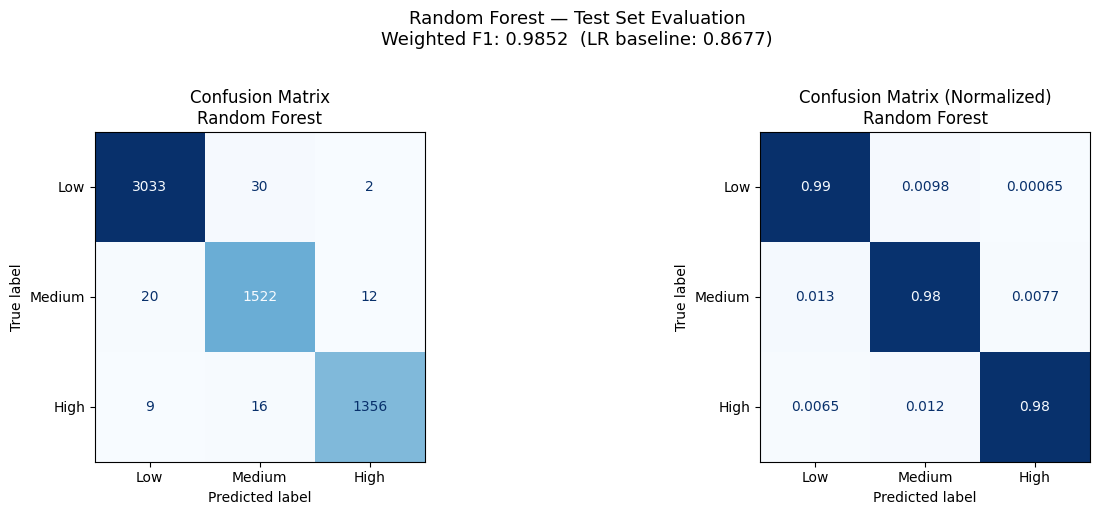


── Error Analysis ──────────────────────────────────
               Pred Low  Pred Medium  Pred High
Actual Low         3033           30          2
Actual Medium        20         1522         12
Actual High           9           16       1356

  Total errors : 89 / 6,000
  Error rate   : 1.48%

  Misclassifications (> 10 cases):
    Actual Low    → Predicted Medium: 30 cases
    Actual Medium → Predicted Low   : 20 cases
    Actual Medium → Predicted High  : 12 cases
    Actual High   → Predicted Medium: 16 cases


In [5]:
print("=" * 55)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("=" * 55)

y_pred       = best_rf.predict(X_test)
y_pred_prob  = best_rf.predict_proba(X_test)

# ── Classification Report ─────────────────────────────
print("\nClassification Report:")
print("─" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Low', 'Medium', 'High'],
    digits=4
))

# ── Key Metrics ───────────────────────────────────────
f1_weighted  = f1_score(y_test, y_pred, average='weighted')
f1_macro     = f1_score(y_test, y_pred, average='macro')
f1_per_class = f1_score(y_test, y_pred, average=None)

print(f"── Summary Metrics ─────────────────────────────────")
print(f"  Weighted F1     : {f1_weighted:.4f}")
print(f"  Macro F1        : {f1_macro:.4f}")
print(f"  F1 — Low        : {f1_per_class[0]:.4f}")
print(f"  F1 — Medium     : {f1_per_class[1]:.4f}")
print(f"  F1 — High       : {f1_per_class[2]:.4f}")

# ── LR Comparison ─────────────────────────────────────
lr_f1        = 0.8677
improvement  = (f1_weighted - lr_f1) * 100
print(f"\n── Comparison vs LR Baseline ───────────────────────")
print(f"  LR Test F1      : {lr_f1:.4f}")
print(f"  RF Test F1      : {f1_weighted:.4f}")
print(f"  Improvement     : {improvement:+.2f} pp")
print(f"  Status          : "
      f"{'✓ Beats LR' if f1_weighted > lr_f1 else '✗ Does not beat LR'}")

# ── Confusion Matrices ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'Medium', 'High']
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\nRandom Forest',
                   fontsize=12)

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Low', 'Medium', 'High']
).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalized)\nRandom Forest',
                   fontsize=12)

plt.suptitle(f'Random Forest — Test Set Evaluation\n'
             f'Weighted F1: {f1_weighted:.4f}  '
             f'(LR baseline: {lr_f1:.4f})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Error Analysis ────────────────────────────────────
print("\n── Error Analysis ──────────────────────────────────")
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual Low','Actual Medium','Actual High'],
    columns = ['Pred Low','Pred Medium','Pred High']
)
print(cm_df)

total_errors = (y_test != y_pred).sum()
print(f"\n  Total errors : {total_errors:,} / {len(y_test):,}")
print(f"  Error rate   : {total_errors/len(y_test)*100:.2f}%")
print(f"\n  Misclassifications (> 10 cases):")
for i, actual in enumerate(['Low','Medium','High']):
    for j, pred in enumerate(['Low','Medium','High']):
        if i != j and cm[i][j] > 10:
            print(f"    Actual {actual:6s} → "
                  f"Predicted {pred:6s}: {cm[i][j]:,} cases")

EXPLAINABILITY — SHAP ANALYSIS
✓ SHAP values computed
  Shape: (6000, 15, 3)


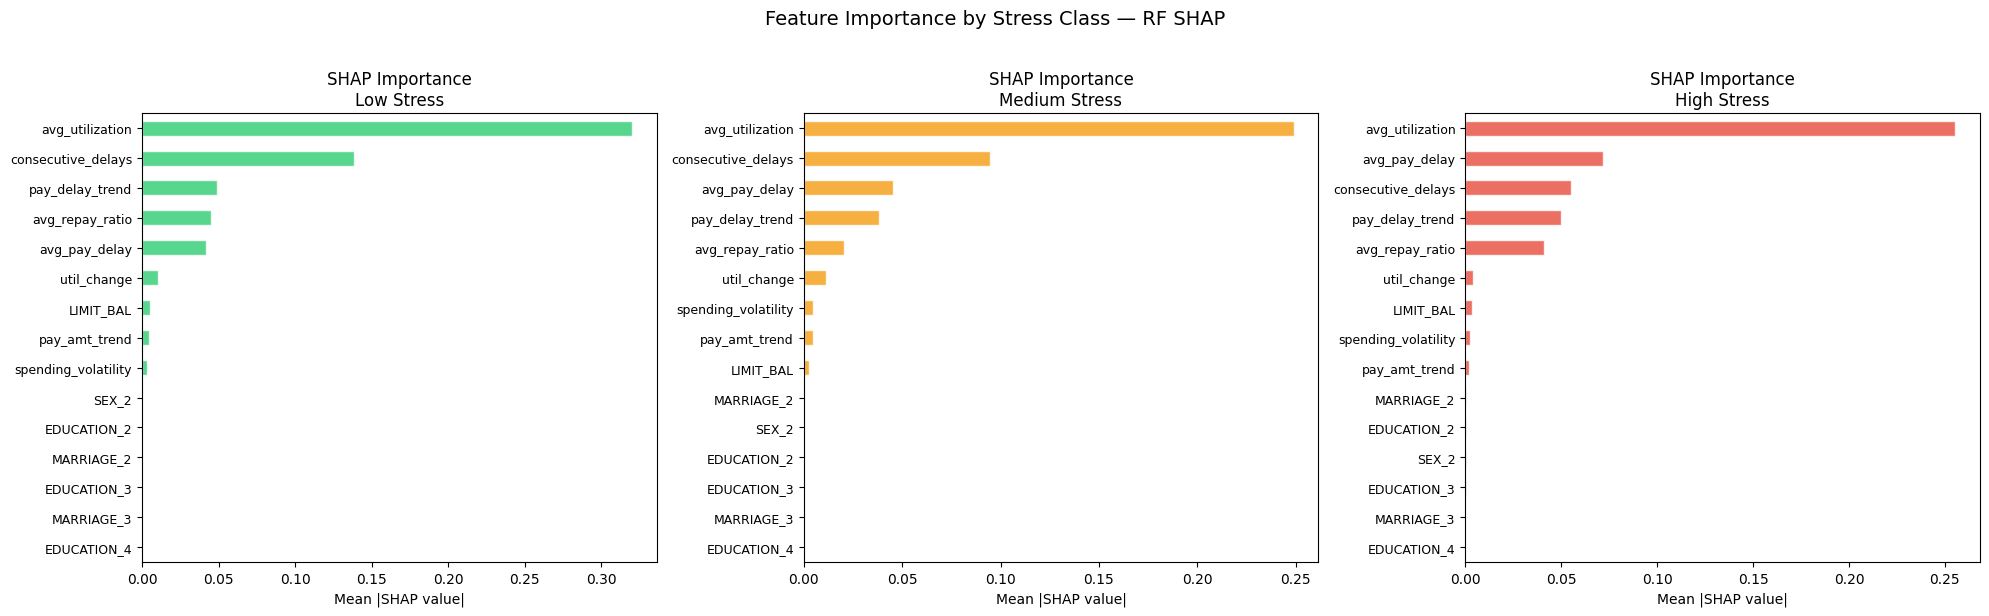

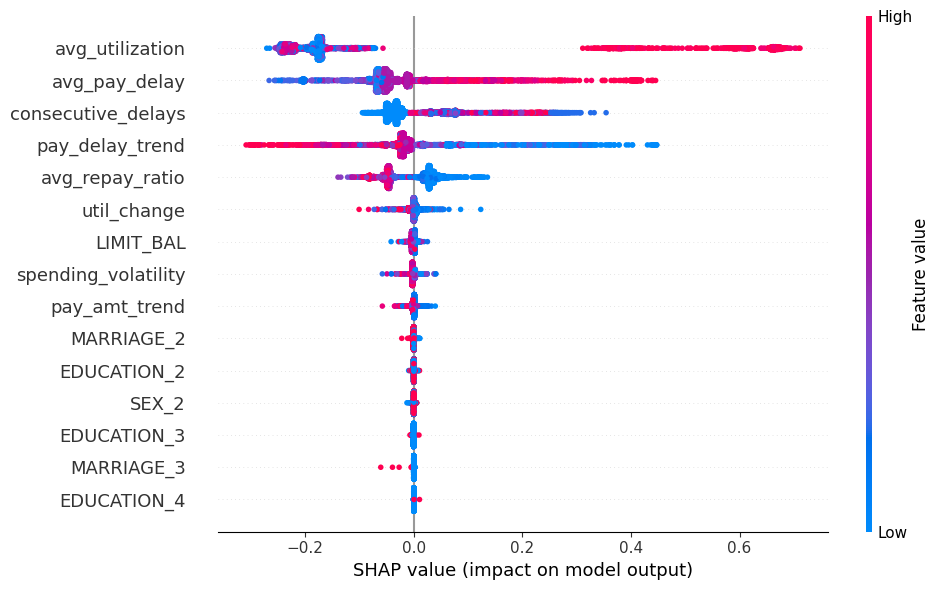


── Top 5 Features per Stress Class ────────────────

  Low Stress:
    - avg_utilization: 0.3200
    avg_utilization           0.3200
    - consecutive_delays: 0.1382
    consecutive_delays        0.1382
    - pay_delay_trend: 0.0487
    pay_delay_trend           0.0487
    - avg_repay_ratio: 0.0452
    avg_repay_ratio           0.0452
    - avg_pay_delay: 0.0415
    avg_pay_delay             0.0415

  Medium Stress:
    - avg_utilization: 0.2490
    avg_utilization           0.2490
    - consecutive_delays: 0.0947
    consecutive_delays        0.0947
    - avg_pay_delay: 0.0454
    avg_pay_delay             0.0454
    - pay_delay_trend: 0.0385
    pay_delay_trend           0.0385
    - avg_repay_ratio: 0.0204
    avg_repay_ratio           0.0204

  High Stress:
    - avg_utilization: 0.2555
    avg_utilization           0.2555
    - avg_pay_delay: 0.0720
    avg_pay_delay             0.0720
    - consecutive_delays: 0.0553
    consecutive_delays        0.0553
    - pay_delay_trend: 0

In [11]:
print("=" * 55)
print("EXPLAINABILITY — SHAP ANALYSIS")
print("=" * 55)

# TreeExplainer is correct for Random Forest
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

print(f"✓ SHAP values computed")
print(f"  Shape: {np.array(shap_values).shape}")

# ── Feature importance bar plots per class ────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
class_names  = ['Low Stress', 'Medium Stress', 'High Stress']
colors_list  = ['#2ecc71', '#f39c12', '#e74c3c']

for i, (cname, color) in enumerate(
        zip(class_names, colors_list)):
    vals = shap_values.values if hasattr(shap_values, 'values') else shap_values
    class_shap = vals[i] if isinstance(vals, list) else vals[:, :, i]
    
    mean_shap = np.abs(class_shap).mean(axis=0)
    feat_imp  = pd.Series(
        mean_shap, index=feature_columns
    ).sort_values(ascending=True)

    feat_imp.plot(kind='barh', ax=axes[i],
                  color=color, alpha=0.8,
                  edgecolor='white')
    axes[i].set_title(f'SHAP Importance\n{cname}',
                      fontsize=12)
    axes[i].set_xlabel('Mean |SHAP value|')
    axes[i].tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importance by Stress Class — RF SHAP',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Beeswarm for High Stress ──────────────────────────
high_stress_shap = shap_values[:, :, 2] if not isinstance(shap_values, list) else shap_values[2]
shap.summary_plot(
    high_stress_shap,
    X_test,
    feature_names=feature_columns,
    plot_type='dot',
    max_display=15,
    show=True,
    plot_size=(10, 6)
)

# ── Top 5 features per class ──────────────────────────
print("\n── Top 5 Features per Stress Class ────────────────")
for i, cname in enumerate(class_names):
    
    # Extract values: newer SHAP versions return a 3D array or Explanation object, older return a list
    vals = shap_values.values if hasattr(shap_values, 'values') else shap_values
    class_shap = vals[:, :, i] if not isinstance(vals, list) else vals[i]
    
    mean_shap = np.abs(class_shap).mean(axis=0)
    top5 = pd.Series(
        mean_shap, index=feature_columns
    ).nlargest(5)
    
    print(f"\n  {cname}:")
    for feat, val in top5.items():
        print(f"    - {feat}: {val:.4f}")
        print(f"    {feat:<25} {val:.4f}")

# ── Compare SHAP rankings with LR ────────────────────
print("\n── SHAP Comparison: RF vs LR ───────────────────────")
print("  High Stress — Top 3 features:")
print(f"  {'Feature':<25} {'LR SHAP':>10} {'RF SHAP':>10}")
print(f"  {'─'*47}")
lr_top3 = {
    'avg_utilization' : 3.5592,
    'avg_pay_delay'   : 2.0493,
    'avg_repay_ratio' : 1.5198
}
vals = shap_values.values if hasattr(shap_values, 'values') else shap_values
rf_high_shap = pd.Series(
    np.abs(vals[:, :, 2] if not isinstance(vals, list) else vals[2]).mean(axis=0),
    index=feature_columns
).nlargest(3)

all_feats = set(list(lr_top3.keys()) + 
                list(rf_high_shap.index))
for feat in all_feats:
    lr_val = lr_top3.get(feat, 0.0)
    rf_val = rf_high_shap.get(feat, 0.0)
    print(f"  {feat:<25} {lr_val:>10.4f} {rf_val:>10.4f}")

print("=" * 55)
print("SAVING MODEL")
print("=" * 55)

os.makedirs('../models/random_forest', exist_ok=True)

joblib.dump(best_rf,
    '../models/random_forest/model.pkl')
joblib.dump(feature_columns,
    '../models/random_forest/feature_columns.pkl')

metadata = {
    "model"           : "Random Forest",
    "task"            : "Stress Detection (Task A)",
    "classes"         : ["Low", "Medium", "High"],
    "date_trained"    : datetime.now().strftime("%Y-%m-%d"),
    "best_params"     : {
        str(k): str(v)
        for k, v in random_search.best_params_.items()
    },
    "cv_f1_weighted"  : round(
        float(random_search.best_score_), 4),
    "test_metrics"    : {
        "weighted_f1" : round(float(f1_weighted), 4),
        "macro_f1"    : round(float(f1_macro), 4),
        "f1_low"      : round(float(f1_per_class[0]), 4),
        "f1_medium"   : round(float(f1_per_class[1]), 4),
        "f1_high"     : round(float(f1_per_class[2]), 4),
        "accuracy"    : round(
            float((y_pred==y_test).mean()), 4),
        "error_rate"  : round(
            float((y_pred!=y_test).mean()), 4)
    },
    "features_used"   : feature_columns,
    "scaling_required": False,
    "notes"           : [
        "Baseline Model 2 — strong non-linear benchmark",
        "Medium class F1 jumped from 0.7563 (LR) to 0.9750",
        "Confirms non-linear structure in stress detection",
        "Train F1=1.0 but test F1=0.9852 — good generalization",
        "Error rate: 1.48% vs LR 13.47%"
    ]
}

with open('../models/random_forest/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"""
╔══════════════════════════════════════════════════════╗
║          RANDOM FOREST — COMPLETE SUMMARY            ║
╠══════════════════════════════════════════════════════╣
║  Task          : Stress Detection (3-class)          ║
║  Dataset       : UCI Credit Card (30,000 customers)  ║
╠══════════════════════════════════════════════════════╣
║  PERFORMANCE                                         ║
║  CV F1 (5-fold): {random_search.best_score_:.4f}                       ║
║  Test F1       : {f1_weighted:.4f}                       ║
║  Test Accuracy : {(y_pred==y_test.values).mean():.4f}                       ║
║  Error Rate    : {(y_pred!=y_test.values).mean():.4f}                       ║
╠══════════════════════════════════════════════════════╣
║  PER CLASS F1                                        ║
║  Low    : {f1_per_class[0]:.4f}                             ║
║  Medium : {f1_per_class[1]:.4f}  (+21.9pp vs LR)           ║
║  High   : {f1_per_class[2]:.4f}                             ║
╠══════════════════════════════════════════════════════╣
║  VS PREVIOUS MODELS                                  ║
║  LR Test F1    : 0.8677                              ║
║  RF Test F1    : {f1_weighted:.4f}  (+11.75pp)              ║
╠══════════════════════════════════════════════════════╣
║  BEST PARAMS                                         ║
║  300 trees, depth=30, features=0.5                  ║
║  balanced, no bootstrap                              ║
╠══════════════════════════════════════════════════════╣
║  ROLE IN PROJECT                                     ║
║  Baseline Model 2 — new benchmark at 0.9852 F1      ║
║  XGBoost + Joint Model must beat this               ║
╚══════════════════════════════════════════════════════╝
""")